# Evolutionary game theory

## 1) Hawk dove

In [103]:
from draw_tree import draw_tree
import pygambit as gbt
import pyspiel
import numpy as np
from open_spiel.python.egt import dynamics
from open_spiel.python.egt.utils import game_payoffs_array
from open_spiel.python.egt.dynamics import time_average
import matplotlib.pyplot as plt

In [180]:
def hawk_dove_game(v, c):

    # Set payoffs
    hawk_dove_p1_payoffs = np.array([[v/2 - c/2, v], [0, v/2]])
    hawk_dove_p2_payoffs = np.array([[v/2 - c/2, 0], [v, v/2]])

    # Generate gambit game
    game_gbt = gbt.Game.from_arrays(
        hawk_dove_p1_payoffs,
        hawk_dove_p2_payoffs,
        title="Hawk dove"
    )

    # Generate openspiel game
    game_ops = pyspiel.create_matrix_game(
        game_gbt.title,
        game_gbt.title,
        [strategy.label for strategy in game_gbt.players[0].strategies],
        [strategy.label for strategy in game_gbt.players[1].strategies],
        hawk_dove_p1_payoffs,
        hawk_dove_p2_payoffs
    )

    return game_gbt, game_ops

In [186]:
def plot_hd_dynamics(
    ops_game,
    proportions,
    steps=100,
    alpha=0.1,
    plot_average_strategy=False,
):

    matrix_hd_payoffs = game_payoffs_array(ops_game)
    hd_dyn = dynamics.SinglePopulationDynamics(matrix_hd_payoffs, dynamics.replicator)

    x = np.array(proportions, dtype=float)

    traj = []

    for _ in range(steps):
        # Euler step
        x = x + alpha * hd_dyn(x)

        # numerical safety: stay on simplex
        x = np.clip(x, 1e-9, None)
        x /= x.sum()

        traj.append(x.copy())

    traj = np.array(traj)

    if plot_average_strategy:
        traj_to_plot = time_average(traj)
    else:
        traj_to_plot = traj

    plt.plot(traj_to_plot[:, 0], label="Hawk")
    plt.plot(traj_to_plot[:, 1], label="Dove")
    plt.ylim(0, 1)
    plt.xlabel("Time step")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

In [184]:
hawk_dove, ops_hawk_dove = hawk_dove_game(4, 2)

In [182]:
hawk_dove

,1,2
1,"1.0,1.0","4.0,0.0"
2,"0.0,4.0","2.0,2.0"


In [185]:
gbt.nash.enummixed_solve(hawk_dove).equilibria[0]

[[Rational(1, 1), Rational(0, 1)], [Rational(1, 1), Rational(0, 1)]]

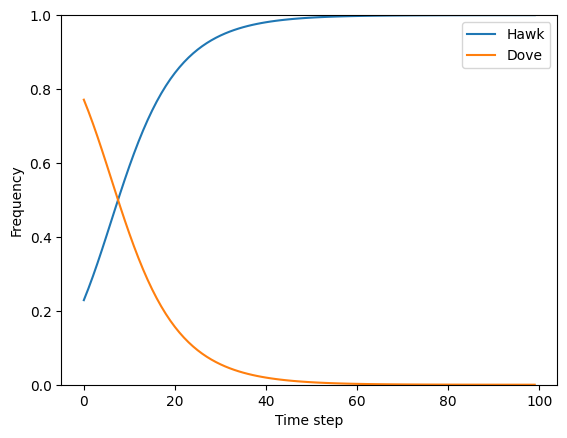

In [188]:
plot_hd_dynamics(ops_hawk_dove, [0.2, 0.8])

# 2) War of attrition

In [192]:
def war_of_attrition_game(v, c):

    # Set payoffs
    wat_p1_payoffs = np.array([[0, 0], [0, wat_v]])
    wat_p2_payoffs = np.array([[wat_v, 0], [wat_v - (wat_c/2), wat_v - (wat_c/2)]])

    # Create gambit game
    game_gbt = gbt.Game.from_arrays(
        wat_p1_payoffs,
        wat_p2_payoffs,
        title="War of attrition"
    )

    # Create openspiel game
    game_ops = pyspiel.create_matrix_game(
        game_gbt.title,
        game_gbt.title,
        [strategy.label for strategy in game_gbt.players[0].strategies],
        [strategy.label for strategy in game_gbt.players[1].strategies],
        wat_p1_payoffs,
        wat_p2_payoffs
    )

    return game_gbt, game_ops

In [195]:
def plot_wat_dynamics(
    ops_game,
    pop1_proportions,
    pop2_proportions,
    steps=100,
    alpha=0.1,
    plot_average_strategy=False,
):
    matrix_wat_payoffs = game_payoffs_array(ops_game)
    wat_dyn = dynamics.MultiPopulationDynamics(matrix_wat_payoffs, dynamics.replicator)

    # Build full state vector
    x = np.concatenate([
        np.array(pop1_proportions),
        np.array(pop2_proportions),
    ])

    ks = matrix_wat_payoffs.shape[1:]  # (2, 2)
    assert x.shape[0] == sum(ks)

    traj = []

    for _ in range(steps):
        x = x + alpha * wat_dyn(x)

        # keep populations normalized (important for Euler steps)
        p1, p2 = np.split(x, np.cumsum(ks)[:-1])
        p1 = np.clip(p1, 1e-9, 1)
        p2 = np.clip(p2, 1e-9, 1)
        p1 /= p1.sum()
        p2 /= p2.sum()
        x = np.concatenate([p1, p2])

        traj.append(x.copy())

    traj = np.array(traj)

    # Extract hawk proportions
    hawk_p1 = traj[:, 0]
    hawk_p2 = traj[:, 2]

    plt.plot(hawk_p1, label="Hawk (population 1)")
    plt.plot(hawk_p2, label="Hawk (population 2)")
    plt.ylim(0, 1)
    plt.xlabel("Time step")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()


In [193]:
wat, ops_wat = war_of_attrition_game(4, 2)

In [194]:
wat

,1,2
1,"0,4.0","0,0.0"
2,"0,3.0","4,3.0"


In [196]:
wat_eqs = gbt.nash.enummixed_solve(wat).equilibria
len(wat_eqs)

3

In [164]:
wat_eqs[1]

[[Rational(0, 1), Rational(1, 1)], [Rational(1, 1), Rational(0, 1)]]

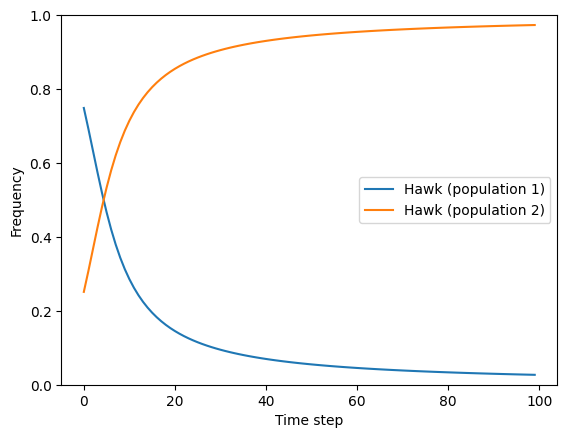

In [197]:
# Finds: wat_eqs[1]
plot_wat_dynamics(
    ops_wat,
    pop1_proportions=[0.8, 0.2],  # Hawk, Dove
    pop2_proportions=[0.2, 0.8],
)